In [1]:
import pandas as pd

# from torch.utils.data import DataLoader
from experiments.sequence_dataset import YieldForecastDataset

df = pd.read_csv("productivity_data_v2.csv")
crop_name = "Пшеница яровая"

train_ds = YieldForecastDataset(
    df=df,
    crop_name=crop_name,
    split="train",
    val_size=0.2,
    seed=42,
    step_days=7,
    windows=(7, 30, 90, 180, 365),
    group_cols=("field_id",),
    stats=("mean", "std", "min", "max", "sum"),  # убрали count
    min_day_from_sowing=30,
)
val_ds = YieldForecastDataset(
    df=df,
    crop_name=crop_name,
    split="val",
    val_size=0.2,
    seed=42,
    step_days=7,
    windows=(7, 30, 90, 180, 365),
    group_cols=("field_id",),
    product_types=train_ds.product_types,
    feature_names=train_ds.feature_names,
    stats=("mean", "std", "min", "max", "sum"),  # убрали count
    min_day_from_sowing=30,
)
# train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

# batch = next(iter(train_loader))
# print(batch["x"].shape)  # (32, F)
# print(batch["mask"].shape)  # (32, F)
# print(batch["y"].shape)  # (32, 1)
# print(f"train samples: {len(train_ds)}, val samples: {len(val_ds)}")
# print(f"features: {len(train_ds.feature_names)}")
# print(train_ds.feature_names[:20])


In [2]:
train_fields = {g["field_id"] for g in train_ds.groups.values()}
val_fields = {g["field_id"] for g in val_ds.groups.values()}
print(f"train fields: {len(train_fields)}")
print(f"val fields:   {len(val_fields)}")
print(f"пересечение:  {len(train_fields & val_fields)}")
print(f"train samples: {len(train_ds)}, val samples: {len(val_ds)}")


train fields: 300
val fields:   81
пересечение:  0
train samples: 4102, val samples: 1096


In [ ]:
import numpy as np
from catboost import CatBoostRegressor, Pool


def dataset_to_numpy(ds):
    xs, masks, ys, years, year_means, prev_prods = [], [], [], [], [], []
    for sample in ds:
        xs.append(sample["x"].numpy())
        masks.append(sample["mask"].numpy())
        ys.append(sample["y"].numpy())
        years.append(sample["year"].numpy())
        year_means.append(sample["year_mean"].numpy())
        prev = sample["meta"]["prev_year_productivity"]
        prev_prods.append([float(prev) if prev is not None else np.nan])

    X = np.stack(xs)
    mask = np.stack(masks)
    y = np.concatenate(ys)
    year_arr = np.stack(years)
    year_mean_arr = np.stack(year_means)
    prev_arr = np.array(prev_prods)

    X_nan = np.where(mask == 1, X, np.nan)
    X_out = np.hstack([X_nan, year_arr, year_mean_arr, prev_arr])
    return X_out, y


X_train, y_train = dataset_to_numpy(train_ds)
X_val, y_val = dataset_to_numpy(val_ds)

feature_names_ext = train_ds.feature_names + [
    "year",
    "year_mean_productivity",
    "prev_year_productivity",
]
train_pool = Pool(X_train, label=y_train, feature_names=feature_names_ext)
val_pool = Pool(X_val, label=y_val, feature_names=feature_names_ext)


# ----------------------------------
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=10,
    min_data_in_leaf=10,
    subsample=0.8,
    colsample_bylevel=0.8,
    nan_mode="Min",
    early_stopping_rounds=200,
    verbose=200,
)

model.fit(train_pool, eval_set=val_pool)


0:	learn: 11.3047822	test: 10.5123326	best: 10.5123326 (0)	total: 2.28ms	remaining: 11.4s
200:	learn: 7.8260453	test: 8.2830027	best: 8.2742426 (191)	total: 398ms	remaining: 9.51s
400:	learn: 6.8304602	test: 8.3287823	best: 8.2518055 (224)	total: 766ms	remaining: 8.78s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 8.251805546
bestIteration = 224

Shrink model to first 225 iterations.


CatBoostRegressor(colsample_bylevel=0.6, depth=4, early_stopping_rounds=300, iterations=5000, l2_leaf_reg=30, learning_rate=0.02, loss_function='RMSE', min_data_in_leaf=30, nan_mode='Min', subsample=0.6, verbose=200)

In [ ]:
# Разбить samples по стадии сезона
for min_day, max_day in [(0, 30), (30, 60), (60, 90), (90, 999)]:
    idx_tr = [
        i
        for i, s in enumerate(train_ds.samples)
        if min_day <= s["day_from_sowing"] < max_day
    ]
    idx_vl = [
        i
        for i, s in enumerate(val_ds.samples)
        if min_day <= s["day_from_sowing"] < max_day
    ]
    if not idx_tr or not idx_vl:
        continue
    pool_tr = Pool(
        X_train[idx_tr], label=y_train[idx_tr], feature_names=feature_names_ext
    )
    pool_vl = Pool(X_val[idx_vl], label=y_val[idx_vl], feature_names=feature_names_ext)
    m = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.02,
        depth=5,
        l2_leaf_reg=10,
        nan_mode="Min",
        early_stopping_rounds=200,
        verbose=0,
    )
    m.fit(pool_tr, eval_set=pool_vl)
    pred = m.predict(X_val[idx_vl])
    rmse = np.sqrt(((pred - y_val[idx_vl]) ** 2).mean())
    r2 = 1 - (rmse**2 / y_val[idx_vl].var())
    print(
        f"day {min_day:3d}-{max_day:3d}: n={len(idx_vl):4d}  RMSE={rmse:.3f}  R²={r2:.3f}"
    )


day  30- 60: n= 405  RMSE=7.487  R²=0.489
day  60- 90: n= 324  RMSE=6.922  R²=0.564
day  90-999: n= 367  RMSE=7.150  R²=0.544


In [9]:
import numpy as np

best_rmse = model.get_best_score()["validation"]["RMSE"]
print(f"best iteration: {model.get_best_iteration()}")
print(f"val RMSE:  {best_rmse:.3f}")
print(f"baseline:  {y_val.std():.3f}")
print(f"R²:        {1 - (best_rmse**2 / y_val.var()):.3f}")
print(f"RMSE/mean: {best_rmse / y_val.mean() * 100:.1f}%")


best iteration: 224
val RMSE:  8.252
baseline:  10.521
R²:        0.385
RMSE/mean: 28.4%


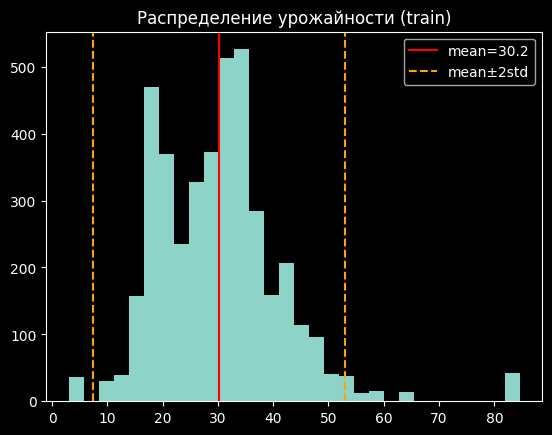

выбросов >mean+2std: 111
выбросов <mean-2std: 37


In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=30)
plt.axvline(y_train.mean(), color="r", label=f"mean={y_train.mean():.1f}")
plt.axvline(
    y_train.mean() + 2 * y_train.std(),
    color="orange",
    linestyle="--",
    label="mean±2std",
)
plt.axvline(y_train.mean() - 2 * y_train.std(), color="orange", linestyle="--")
plt.legend()
plt.title("Распределение урожайности (train)")
plt.show()

print(f"выбросов >mean+2std: {(y_train > y_train.mean() + 2 * y_train.std()).sum()}")
print(f"выбросов <mean-2std: {(y_train < y_train.mean() - 2 * y_train.std()).sum()}")


In [6]:
# Посмотреть что разделяет два пика
import pandas as pd

df_train_meta = pd.DataFrame(
    [
        {
            **train_ds.groups[s["group_key"]],
            "y": train_ds.groups[s["group_key"]]["productivity"],
        }
        for s in train_ds.samples
    ]
).drop_duplicates(subset=["field_id", "year"])

# Может разделяется по году?
print(df_train_meta.groupby("year")["y"].describe())

# Или по региону (если есть)?
# print(df_train_meta.groupby("region")["y"].describe())

# Просто посмотреть на поля с низкой урожайностью
low = df_train_meta[df_train_meta["y"] < 15]
high = df_train_meta[df_train_meta["y"] > 25]
print(f"низкая (<15): {len(low)} полей")
print(f"высокая (>25): {len(high)} полей")
print(low[["field_id", "field_name", "year", "y"]].head(10))


      count       mean        std        min        25%        50%        75%  \
year                                                                            
2020    2.0   8.590000   7.919596   2.990000   5.790000   8.590000  11.390000   
2021   74.0  34.152696   7.195637  15.857778  30.769665  33.941231  35.929780   
2022   56.0  33.346226   8.116954  15.733333  28.511274  33.496567  38.663654   
2023   85.0  20.298870   5.362576   4.579000  17.378261  18.800000  22.642857   
2024   60.0  33.695213  15.532843  12.253846  24.342444  31.800924  37.997857   
2025   23.0  35.560003  11.381508   4.794915  28.070758  36.302963  43.581167   

            max  
year             
2020  14.190000  
2021  55.088889  
2022  49.725000  
2023  35.257143  
2024  84.565789  
2025  52.717949  
низкая (<15): 13 полей
высокая (>25): 193 полей
      field_id                            field_name  year          y
235        230                     Бригадная стрелка  2023  11.861413
319        239     

In [10]:
importances = model.get_feature_importance(train_pool)
top = sorted(zip(feature_names_ext, importances), key=lambda x: -x[1])
for name, imp in top:
    print(f"{imp:6.2f}  {name}")


  8.92  year_mean_productivity
  8.89  ndvi__dim0__w180__max
  6.96  ndvi__dim0__w365__max
  5.18  ndvi__dim0__w90__max
  4.81  ndvi_s2a__dim0__w365__min
  3.90  ndvi_l8__dim0__w365__min
  3.09  ndvi_l8__dim0__w365__mean
  2.71  ndvi_l8__dim0__w180__min
  2.63  soil_moisture__dim3__w365__max
  2.39  ndvi_l8__dim0__w365__std
  2.25  soil_moisture__dim0__w365__std
  1.89  ndvi_s2b__dim0__w365__min
  1.82  ndvi_l8__dim0__w180__max
  1.68  soil_moisture__dim2__w180__min
  1.68  ndvi_l8__dim0__w90__std
  1.58  soil_moisture__dim3__w365__min
  1.56  soil_moisture__dim3__w90__max
  1.56  ndvi_l8__dim0__w365__max
  1.40  ndvi__dim0__w365__std
  1.27  ndvi_l8__dim0__w180__sum
  1.26  ndvi__dim0__w180__std
  1.18  soil_moisture__dim1__w365__std
  1.16  ndvi_l8__dim0__w180__mean
  1.09  soil_moisture__dim3__w180__min
  1.02  ndvi__dim0__w90__sum
  1.00  soil_moisture__dim2__w365__min
  0.83  ndvi_s2a__dim0__w180__std
  0.77  ndvi_l8__dim0__latest
  0.75  soil_moisture__dim3__w30__min
  0.74  soil

In [8]:
print(f"y std: {y_train.std():.2f}, mean: {y_train.mean():.2f}")
print(f"baseline (predict mean) RMSE: {y_val.std():.2f}")


y std: 11.37, mean: 30.16
baseline (predict mean) RMSE: 10.52


In [ ]:
years_per_field = df.groupby("field_id")["year"].nunique()
print(years_per_field.value_counts())


year
5    144
1    114
3     84
2     70
4     34
6      7
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("productivity_data_v2.csv")


,field_id,field_name,field_calculated_area,crop_id,crop_name,year,previous_crop_id,previous_crop_name,sowing_date,harvesting_date,productivity,historical_values.product_type,historical_values.value
3620,1009,"""Агрошанс"" с препаратом Луч",8.42895,43,Пшеница яровая,2021,40,Подсолнечник,2021-05-06,2021-08-20,35.964706,ndvi,"[[""2021-04-14"", 0.179], [""2021-04-16"", 0.178],..."
3621,1009,"""Агрошанс"" с препаратом Луч",8.42895,43,Пшеница яровая,2021,40,Подсолнечник,2021-05-06,2021-08-20,35.964706,temperature,"[[""2021-01-01"", -27.6], [""2021-01-04"", -33.4],..."
3622,1009,"""Агрошанс"" с препаратом Луч",8.42895,43,Пшеница яровая,2023,40,Подсолнечник,2023-05-08,2023-08-10,21.070588,ndvi,"[[""2023-04-06"", 0.158], [""2023-04-10"", 0.168],..."
3623,1009,"""Агрошанс"" с препаратом Луч",8.42895,43,Пшеница яровая,2023,40,Подсолнечник,2023-05-08,2023-08-10,21.070588,temperature,"[[""2023-01-11"", -30.3], [""2023-01-24"", -21.3],..."
3624,1010,"""Агрошанс"" с препаратом Луч 2",10.22755,43,Пшеница яровая,2021,40,Подсолнечник,2021-05-08,2021-08-30,31.960000,ndvi,"[[""2021-04-16"", 0.169], [""2021-04-18"", 0.175],..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6890,365,Штаны Серов,60.80782,43,Пшеница яровая,2025,40,Подсолнечник,2025-05-14,2025-09-14,40.233333,ndvi_s2a,"[[""2025-03-31"", 0.034], [""2025-04-20"", 0.195],..."
6891,365,Штаны Серов,60.80782,43,Пшеница яровая,2025,40,Подсолнечник,2025-05-14,2025-09-14,40.233333,ndvi_s2b,"[[""2025-01-06"", 0.043], [""2025-01-13"", 0.065],..."
6892,365,Штаны Серов,60.80782,43,Пшеница яровая,2025,40,Подсолнечник,2025-05-14,2025-09-14,40.233333,ndvi_s2c,"[[""2025-02-17"", 0.084], [""2025-03-02"", 0.085],..."
6893,365,Штаны Серов,60.80782,43,Пшеница яровая,2025,40,Подсолнечник,2025-05-14,2025-09-14,40.233333,soil_moisture,"[[""2025-01-01"", [0.033, 0.36, 0.697, 0.781]], ..."


In [5]:
# сначала убираем дубликаты мета-полей
df_meta = df[["field_id", "year", "field_name", "crop_name", 
              "sowing_date", "harvesting_date", "productivity",
              "previous_crop_name"]].drop_duplicates()

# пивотим временные ряды
df_wide = df.pivot_table(
    index=["field_id", "year"],
    columns="historical_values.product_type",
    values="historical_values.value",
    aggfunc="first"  # берём первое значение (дубликатов по полю+год+тип быть не должно)
)

# убираем иерархию в колонках
df_wide.columns.name = None
df_wide = df_wide.reset_index()

# мержим с метаданными
df_result = pd.merge(df_meta, df_wide, on=["field_id", "year"], how="left")
df_result


,field_id,year,field_name,crop_name,sowing_date,harvesting_date,productivity,previous_crop_name,ndvi,ndvi_l8,ndvi_ps8,ndvi_s2a,ndvi_s2b,ndvi_s2c,soil_moisture,temperature
0,909,2024,"Адамова бригада 2-1/31, 2-3/16 (Метлишино)",Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,12.876000,Пшеница яровая,"[[""2024-04-15"", 0.199], [""2024-04-17"", 0.215],...",NaN,"[[""2024-04-15"", 0.149], [""2024-04-17"", 0.157],...","[[""2024-01-15"", 0.101], [""2024-02-01"", 0.097],...","[[""2024-01-20"", 0.08], [""2024-01-27"", 0.066], ...",NaN,"[[""2024-01-01"", [0.326, 0.202, 0.41, 0.489]], ...","[[""2024-01-09"", -25.6], [""2024-01-14"", -22.3],..."
1,904,2024,Асфальтированная площадка 1-3,Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,14.166327,Пшеница яровая,"[[""2024-04-15"", 0.166], [""2024-04-17"", 0.178],...",NaN,"[[""2024-04-15"", 0.137], [""2024-04-20"", 0.157],...","[[""2024-01-15"", 0.101], [""2024-02-01"", 0.095],...","[[""2024-01-20"", 0.082], [""2024-01-27"", 0.081],...",NaN,"[[""2024-01-01"", [0.327, 0.203, 0.417, 0.49]], ...","[[""2024-01-09"", -25.3], [""2024-01-14"", -22.1],..."
2,896,2024,Асфальтированная площадка 1-4/46 (Метлишино),Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,19.372727,Пшеница яровая,"[[""2024-04-15"", 0.173], [""2024-04-17"", 0.175],...",NaN,"[[""2024-04-15"", 0.143], [""2024-04-16"", 0.156],...","[[""2024-01-15"", 0.104], [""2024-02-01"", 0.096],...","[[""2024-01-20"", 0.086], [""2024-01-27"", 0.083],...",NaN,"[[""2024-01-01"", [0.328, 0.205, 0.423, 0.491]],...","[[""2024-01-09"", -25.15], [""2024-01-14"", -22.0]..."
3,900,2024,Асфальтированная площадка 2-5/54 (Метлишино),Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,4.117647,Пшеница яровая,"[[""2024-04-15"", 0.176], [""2024-04-17"", 0.184],...",NaN,"[[""2024-04-15"", 0.147], [""2024-04-17"", 0.155],...","[[""2024-01-15"", 0.106], [""2024-02-01"", 0.095],...","[[""2024-01-20"", 0.082], [""2024-01-27"", 0.082],...",NaN,"[[""2024-01-01"", [0.329, 0.205, 0.424, 0.491]],...","[[""2024-01-02"", -14.9], [""2024-01-06"", -22.8],..."
4,925,2025,Городская 5-2,Чечевица,2025-05-04 00:00:00,2025-08-27 00:00:00,16.365657,Пшеница яровая,"[[""2025-03-30"", 0.169], [""2025-04-06"", 0.17], ...",NaN,"[[""2025-04-02"", 0.18], [""2025-04-09"", 0.166], ...","[[""2025-01-16"", 0.084], [""2025-01-19"", 0.08], ...","[[""2025-01-11"", 0.06], [""2025-01-14"", 0.074], ...","[[""2025-04-06"", 0.166], [""2025-04-09"", 0.177],...","[[""2025-01-01"", [0.0, 0.109, 0.476, 0.642]], [...","[[""2025-01-08"", -20.75], [""2025-01-11"", -14.1]..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1399,670,2023,Щебенка 4-1/152,Гречиха,2023-05-22 00:00:00,2023-09-22 00:00:00,7.734286,Пшеница яровая,"[[""2023-04-06"", 0.133], [""2023-04-07"", 0.136],...","[[""2023-03-10"", 0.018], [""2023-03-26"", 0.08], ...","[[""2023-04-08"", 0.162], [""2023-04-09"", 0.153],...","[[""2023-01-10"", 0.11], [""2023-01-17"", 0.105], ...","[[""2023-01-05"", 0.033], [""2023-02-11"", 0.057],...",NaN,"[[""2023-01-01"", [0.0, 0.0, 0.043, 0.558]], [""2...","[[""2023-01-01"", -25.1], [""2023-01-04"", -16.3],..."
1400,302,2024,Котлован,Пшеница яровая (твердая),2024-05-18 00:00:00,2024-08-23 00:00:00,43.846154,Пшеница яровая,"[[""2024-04-12"", 0.19], [""2024-04-14"", 0.191], ...",NaN,"[[""2024-04-14"", 0.179], [""2024-04-15"", 0.172],...","[[""2024-01-24"", 0.091], [""2024-02-06"", 0.085],...","[[""2024-01-22"", 0.089], [""2024-03-22"", 0.068],...",NaN,"[[""2024-01-01"", [0.482, 0.348, 0.691, 0.841]],...","[[""2024-01-05"", -5.6], [""2024-01-16"", -23.4], ..."
1401,332,2024,Крутиха,Пшеница яровая (твердая),2024-05-10 00:00:00,2024-08-21 00:00:00,44.753879,Пшеница яровая,"[[""2024-04-12"", 0.18], [""2024-04-14"", 0.184], ...",NaN,"[[""2024-04-14"", 0.17], [""2024-04-15"", 0.167], ...","[[""2024-01-17"", 0.109], [""2024-01-24"", 0.091],...","[[""2024-01-22"", 0.089], [""2024-02-28"", 0.094],...",NaN,"[[""2024-01-01"", [0.483, 0.348, 0.691, 0.844]],...","[[""2024-01-05"", -5.6], [""2024-01-12"", -21

In [7]:
crop_name = "Пшеница яровая"

df_crop = df_result[df_result["crop_name"] == crop_name].copy()
df_crop.harvesting_date = pd.to_datetime(df_crop.harvesting_date)
df_crop.sowing_date = pd.to_datetime(df_crop.sowing_date)
df_crop


,field_id,year,field_name,crop_name,sowing_date,harvesting_date,productivity,previous_crop_name,ndvi,ndvi_l8,ndvi_ps8,ndvi_s2a,ndvi_s2b,ndvi_s2c,soil_moisture,temperature
653,1009,2021,"""Агрошанс"" с препаратом Луч",Пшеница яровая,2021-05-06,2021-08-20,35.964706,Подсолнечник,"[[""2021-04-14"", 0.179], [""2021-04-16"", 0.178],...",NaN,NaN,NaN,NaN,NaN,NaN,"[[""2021-01-01"", -27.6], [""2021-01-04"", -33.4],..."
654,1009,2023,"""Агрошанс"" с препаратом Луч",Пшеница яровая,2023-05-08,2023-08-10,21.070588,Подсолнечник,"[[""2023-04-06"", 0.158], [""2023-04-10"", 0.168],...",NaN,NaN,NaN,NaN,NaN,NaN,"[[""2023-01-11"", -30.3], [""2023-01-24"", -21.3],..."
655,1010,2021,"""Агрошанс"" с препаратом Луч 2",Пшеница яровая,2021-05-08,2021-08-30,31.960000,Подсолнечник,"[[""2021-04-16"", 0.169], [""2021-04-18"", 0.175],...",NaN,NaN,NaN,NaN,NaN,NaN,"[[""2021-01-01"", -27.0], [""2021-01-03"", -33.1],..."
656,1010,2024,"""Агрошанс"" с препаратом Луч 2",Пшеница яровая,2024-05-17,2024-09-14,40.175714,Подсолнечник,"[[""2024-04-12"", 0.177], [""2024-04-14"", 0.181],...",NaN,NaN,NaN,NaN,NaN,"[[""2024-01-01"", [0.486, 0.347, 0.688, 0.838]],...","[[""2024-01-05"", -6.4], [""2024-01-12"", -21.2], ..."
657,273,2025,1-я речка,Пшеница яровая,2025-05-13,2025-09-19,44.196296,Подсолнечник,"[[""2025-04-13"", 0.184], [""2025-04-16"", 0.184],...",NaN,NaN,"[[""2025-03-31"", 0.045], [""2025-04-20"", 0.205],...","[[""2025-01-13"", 0.083], [""2025-01-16"", 0.08], ...","[[""2025-02-07"", 0.075], [""2025-02-17"", 0.075],...","[[""2025-01-01"", [0.038, 0.366, 0.699, 0.795]],...","[[""2025-01-04"", -6.2], [""2025-01-05"", -14.25],..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1257,364,2025,Широкий лог,Пшеница яровая,2025-05-16,2025-09-08,50.883333,Подсолнечник,"[[""2025-04-16"", 0.138], [""2025-04-20"", 0.142],...",NaN,"[[""2025-04-22"", 0.26], [""2025-04-25"", 0.224], ...","[[""2025-03-31"", 0.037], [""2025-04-20"", 0.193],...","[[""2025-01-06"", 0.029], [""2025-01-13"", 0.046],...","[[""2025-02-07"", 0.068], [""2025-02-17"", 0.069],...","[[""2025-01-01"", [0.034, 0.361, 0.696, 0.781]],...","[[""2025-01-05"", -18.7], [""2025-01-09"", -15.3],..."
1258,342,2023,ШКМ,Пшеница яровая,2023-05-13,2023-09-01,23.409091,Подсолнечник,"[[""2023-04-04"", 0.153], [""2023-04-25"", 0.231],...","[[""2023-03-29"", 0.082], [""2023-06-01"", 0.43], ...","[[""2023-04-25"", 0.197], [""2023-04-28"", 0.174],...","[[""2023-01-29"", 0.082], [""2023-02-11"", 0.084],...","[[""2023-01-27"", 0.079], [""2023-02-13"", 0.097],...",NaN,"[[""2023-01-01"", [0.059, 0.219, 0.511, 0.692]],...","[[""2023-01-22"", -29.6], [""2023-01-24"", -20.5],..."
1259,226,2022,Штаны,Пшеница яровая,2022-05-13,2022-08-25,16.935000,Подсолнечник,"[[""2022-04-23"", 0.174], [""2022-04-24"", 0.174],...",NaN,NaN,NaN,NaN,NaN,"[[""2022-01-01"", [0.0, 0.296, 0.638, 0.755]], [...","[[""2022-01-01"", -23.0], [""2022-01-02"", -11.2],..."
1260,365,2022,Штаны Серов,Пшеница яровая,2022-05-17,2022-08-30,38.606667,Подсолнечник,"[[""2022-04-23"", 0.162], [""2022-04-24"", 0.165],...",NaN,NaN,NaN,NaN,NaN,"[[""2022-01-01"", [0.0, 0.297, 0.648, 0.758]], [...","[[""2022-01-01"", -26.0], [""2022-01-02"", -22.8],..."


In [ ]:
df_result


,field_id,year,field_name,crop_name,sowing_date,harvesting_date,productivity,previous_crop_name,ndvi,ndvi_l8,ndvi_ps8,ndvi_s2a,ndvi_s2b,ndvi_s2c,temperature,soil_ch0,soil_ch1,soil_ch2,soil_ch3
0,909,2024,"Адамова бригада 2-1/31, 2-3/16 (Метлишино)",Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,12.876000,Пшеница яровая,"[[""2024-04-15"", 0.199], [""2024-04-17"", 0.215],...",NaN,"[[""2024-04-15"", 0.149], [""2024-04-17"", 0.157],...","[[""2024-01-15"", 0.101], [""2024-02-01"", 0.097],...","[[""2024-01-20"", 0.08], [""2024-01-27"", 0.066], ...",NaN,"[[""2024-01-09"", -25.6], [""2024-01-14"", -22.3],...",None,None,None,None
1,904,2024,Асфальтированная площадка 1-3,Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,14.166327,Пшеница яровая,"[[""2024-04-15"", 0.166], [""2024-04-17"", 0.178],...",NaN,"[[""2024-04-15"", 0.137], [""2024-04-20"", 0.157],...","[[""2024-01-15"", 0.101], [""2024-02-01"", 0.095],...","[[""2024-01-20"", 0.082], [""2024-01-27"", 0.081],...",NaN,"[[""2024-01-09"", -25.3], [""2024-01-14"", -22.1],...",None,None,None,None
2,896,2024,Асфальтированная площадка 1-4/46 (Метлишино),Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,19.372727,Пшеница яровая,"[[""2024-04-15"", 0.173], [""2024-04-17"", 0.175],...",NaN,"[[""2024-04-15"", 0.143], [""2024-04-16"", 0.156],...","[[""2024-01-15"", 0.104], [""2024-02-01"", 0.096],...","[[""2024-01-20"", 0.086], [""2024-01-27"", 0.083],...",NaN,"[[""2024-01-09"", -25.15], [""2024-01-14"", -22.0]...",None,None,None,None
3,900,2024,Асфальтированная площадка 2-5/54 (Метлишино),Чечевица,2024-05-11 00:00:00,2024-09-12 00:00:00,4.117647,Пшеница яровая,"[[""2024-04-15"", 0.176], [""2024-04-17"", 0.184],...",NaN,"[[""2024-04-15"", 0.147], [""2024-04-17"", 0.155],...","[[""2024-01-15"", 0.106], [""2024-02-01"", 0.095],...","[[""2024-01-20"", 0.082], [""2024-01-27"", 0.082],...",NaN,"[[""2024-01-02"", -14.9], [""2024-01-06"", -22.8],...",None,None,None,None
4,925,2025,Городская 5-2,Чечевица,2025-05-04 00:00:00,2025-08-27 00:00:00,16.365657,Пшеница яровая,"[[""2025-03-30"", 0.169], [""2025-04-06"", 0.17], ...",NaN,"[[""2025-04-02"", 0.18], [""2025-04-09"", 0.166], ...","[[""2025-01-16"", 0.084], [""2025-01-19"", 0.08], ...","[[""2025-01-11"", 0.06], [""2025-01-14"", 0.074], ...","[[""2025-04-06"", 0.166], [""2025-04-09"", 0.177],...","[[""2025-01-08"", -20.75], [""2025-01-11"", -14.1]...",None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1399,670,2023,Щебенка 4-1/152,Гречиха,2023-05-22 00:00:00,2023-09-22 00:00:00,7.734286,Пшеница яровая,"[[""2023-04-06"", 0.133], [""2023-04-07"", 0.136],...","[[""2023-03-10"", 0.018], [""2023-03-26"", 0.08], ...","[[""2023-04-08"", 0.162], [""2023-04-09"", 0.153],...","[[""2023-01-10"", 0.11], [""2023-01-17"", 0.105], ...","[[""2023-01-05"", 0.033], [""2023-02-11"", 0.057],...",NaN,"[[""2023-01-01"", -25.1], [""2023-01-04"", -16.3],...",None,None,None,None
1400,302,2024,Котлован,Пшеница яровая (твердая),2024-05-18 00:00:00,2024-08-23 00:00:00,43.846154,Пшеница яровая,"[[""2024-04-12"", 0.19], [""2024-04-14"", 0.191], ...",NaN,"[[""2024-04-14"", 0.179], [""2024-04-15"", 0.172],...","[[""2024-01-24"", 0.091], [""2024-02-06"", 0.085],...","[[""2024-01-22"", 0.089], [""2024-03-22"", 0.068],...",NaN,"[[""2024-01-05"", -5.6], [""2024-01-16"", -23.4], ...",None,None,None,None
1401,332,2024,Крутиха,Пшеница яровая (твердая),2024-05-10 00:00:00,2024-08-21 00:00:00,44.753879,Пшеница яровая,"[[""2024-04-12"", 0.18], [""2024-04-14"", 0.184], ...",NaN,"[[""2024-04-14"", 0.17], [""2024-04-15"", 0.167], ...","[[""2024-01-17"", 0.109], [""2024-01-24"", 0.091],...","[[""2024-01-22"", 0.089], [""2024-02-28"", 0.094],...",NaN,"[[""2024-01-05"", -5.6], [""2024-01-12"", -21.6], ...",None,None,None,None
1402,726,2024,Тегерек 11-1,Пшеница яровая (твердая),2024-05-21 00:00:00,2024-08-30 00:00:00,24.810294,Соя,"[[""2024-04-15"", 0.166], [""2024-04-16"", 0.168],...",NaN,NaN,"[[""2024-02-11"", 0.092], [""2024-04-11"", 0.108],...","[[

In [3]:
df_grouped = df_crop.groupby(
    [
        "field_id",
        "field_name",
        "field_calculated_area",
        "crop_id",
        "crop_name",
        "sowing_date",
        "harvesting_date",
        "productivity",
    ]
)
df_grouped


In [11]:
productivity = df_crop.productivity
harvesting_date = df_crop.harvesting_date


In [12]:
productivity.describe()


count    596.000000
mean      30.625430
std       11.767813
min        0.081967
25%       21.206134
50%       31.407138
75%       38.582735
max       84.565789
Name: productivity, dtype: float64

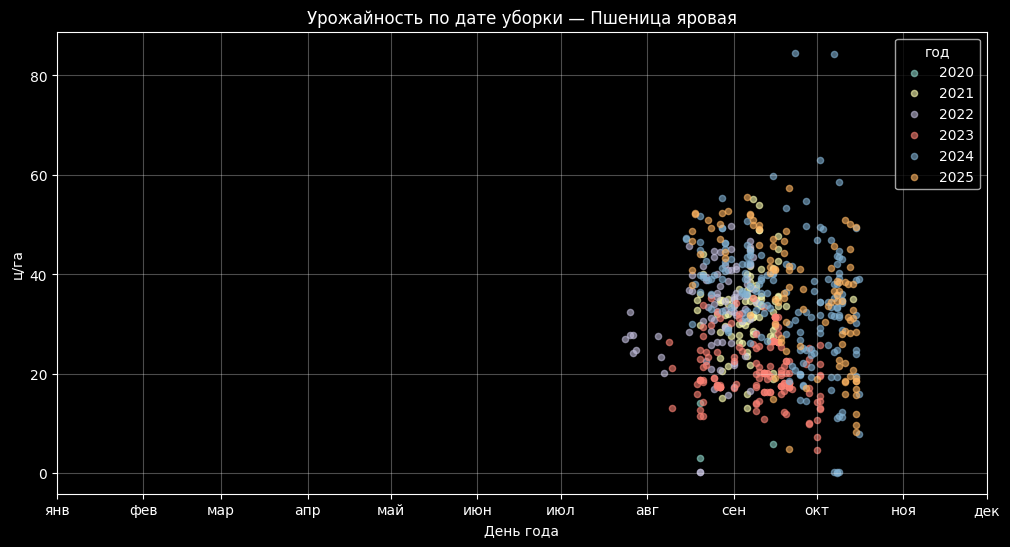

In [ ]:
df_prod = df_crop[
    ["field_id", "year", "harvesting_date", "productivity"]
].drop_duplicates()
df_prod["harvesting_date"] = pd.to_datetime(df_prod["harvesting_date"])

fig, ax = plt.subplots(figsize=(12, 6))

for year, group in df_prod.groupby("year"):
    ax.scatter(
        group["harvesting_date"].dt.dayofyear,
        group["productivity"],
        alpha=0.6,
        s=20,
        label=str(year),
    )

ax.set_title(f"Урожайность по дате уборки — {crop_name}")
ax.set_xlabel("День года")
ax.set_ylabel("ц/га")

# подписи месяцев по оси X
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = [
    "янв",
    "фев",
    "мар",
    "апр",
    "май",
    "июн",
    "июл",
    "авг",
    "сен",
    "окт",
    "ноя",
    "дек",
]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)

ax.legend(title="год")
ax.grid(True, alpha=0.3)
plt.show()
